# PCA Sensitivity Analysis - Pathology Classification

## Objective
Evaluate the trade-off: does PCA transformation that mitigates site effects hurt pathology classification?

## Experiment Design
- **Methods tested:** raw, sitewise, combat, neurocombat, covbat
- **PCA variants:** none, all (full), 0.99, 0.95, 0.90, 0.80
- **Metric:** Pathology classification AUC (higher = better)

## Key Results

| Method | No PCA | PCA 0.80 |
|--------|--------|----------|
| raw | 0.803 | 0.772 |
| combat | **0.811** | 0.782 |
| sitewise | 0.806 | 0.782 |

## Trade-off Analysis
- **Site MCC reduction:** 0.957 → 0.564 (ComBat with PCA 0.80)
- **Pathology AUC cost:** 0.811 → 0.782 (~3% drop)

The trade-off exists but may be acceptable depending on the use case. PCA helps site-invariance at a modest pathology cost.

## Conclusion
PCA transformation offers a partial solution to the paradox, but a better approach (like DANN) could potentially achieve site-invariance without sacrificing pathology performance.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = 'results/tables/05_pca_sensitivity/pca_sensitivity_results_patho_full_single_catboost.csv'
FIGURES_DIR  = 'results/figures/05_pca_sensitivity/pathology_classification'

METHODS      = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']
PCA_VARIANTS = ['none', 'all', '0.99', '0.95', '0.9', '0.8']

COLOR_GRID = ['black', 'tomato', 'skyblue', 'green', 'orange', 'purple', 'brown', 'cyan']

In [3]:
patho_df = pd.read_csv(RESULTS_PATH)
print(patho_df.shape, patho_df['pca_var'].unique())

(900, 12) ['none' 'all' '0.99' '0.95' '0.9' '0.8']


## Pathology AUC per hospital — grouped by method

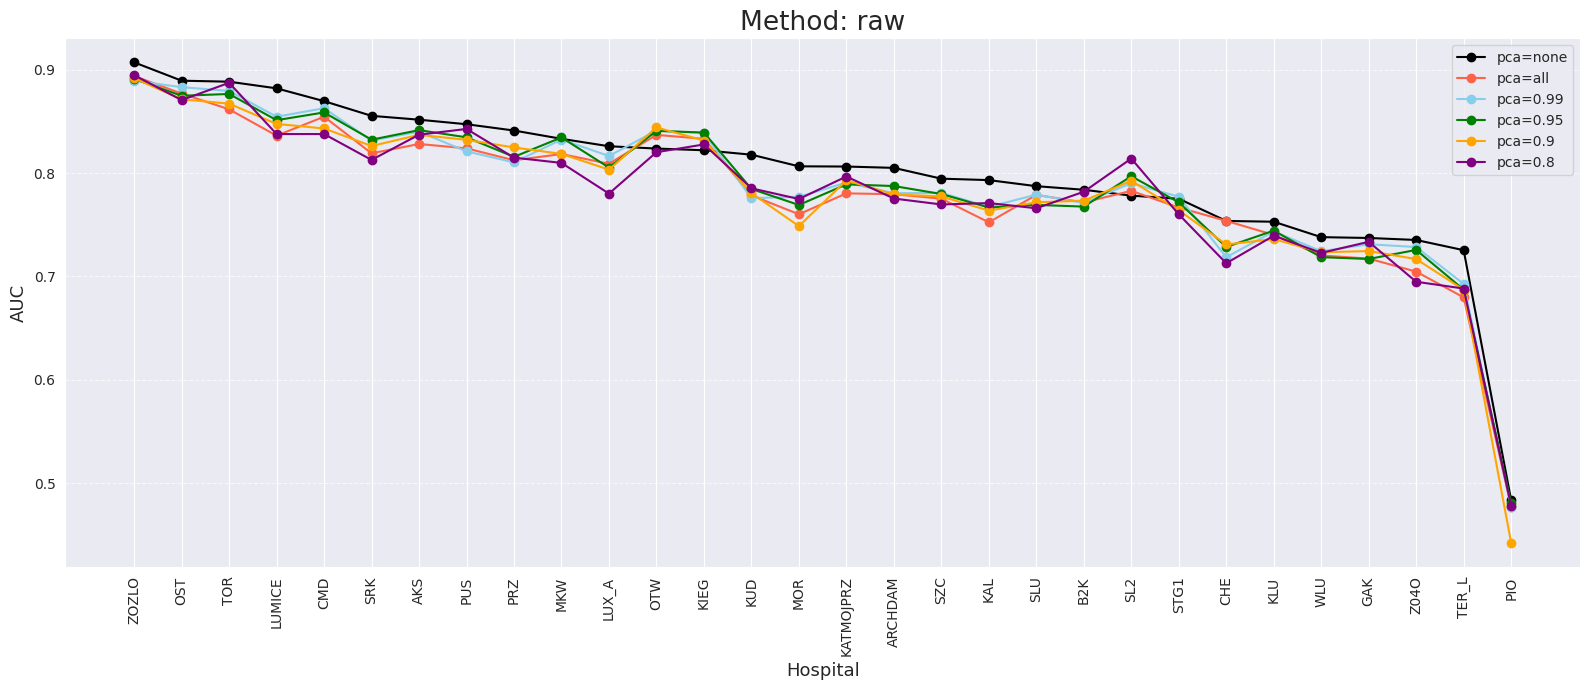

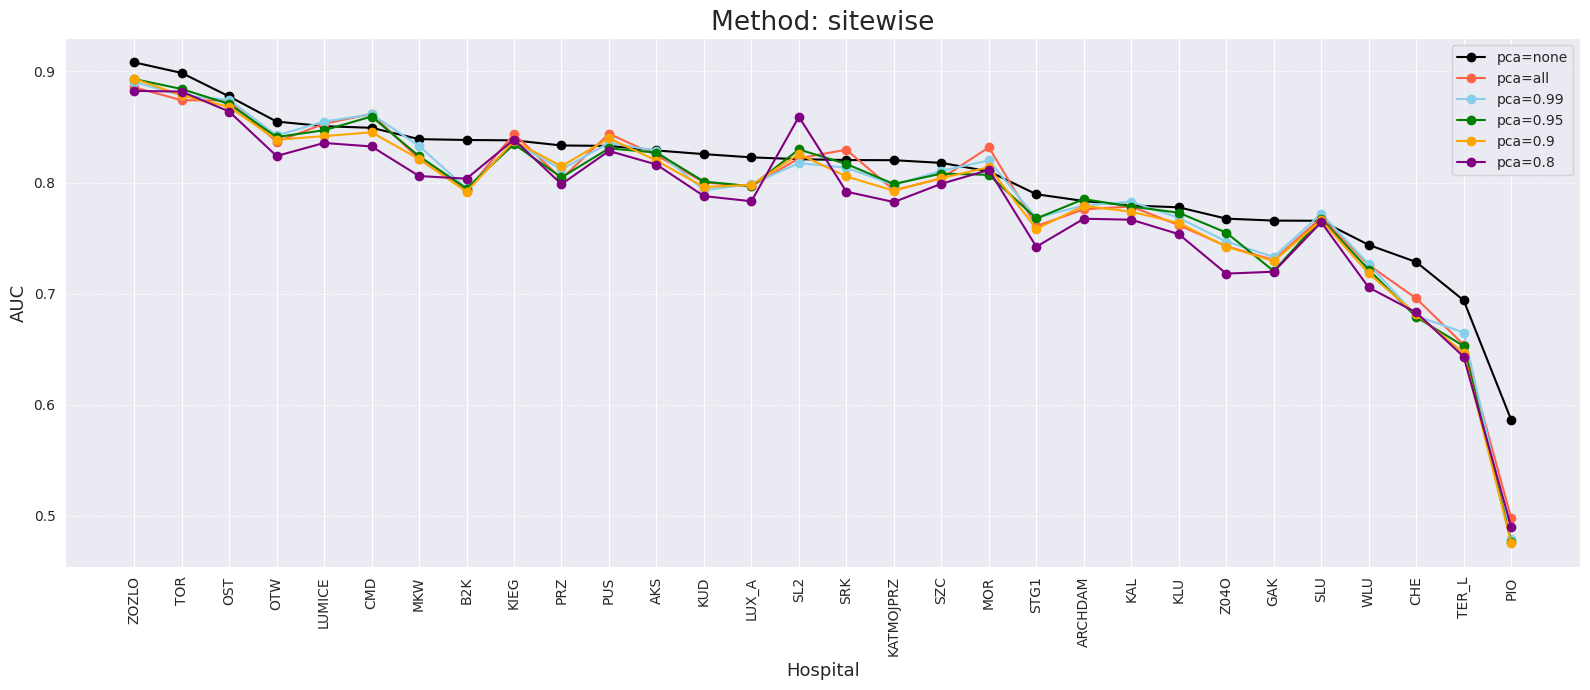

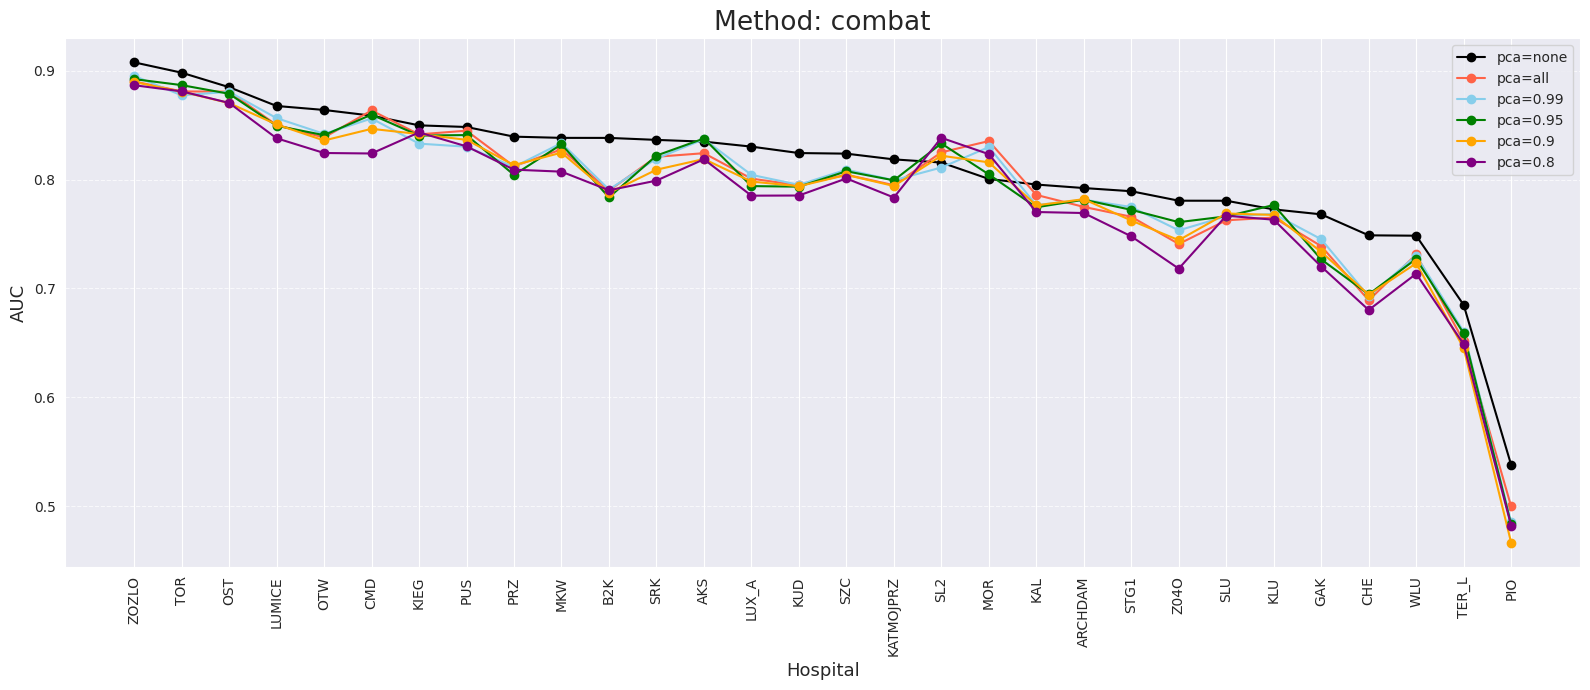

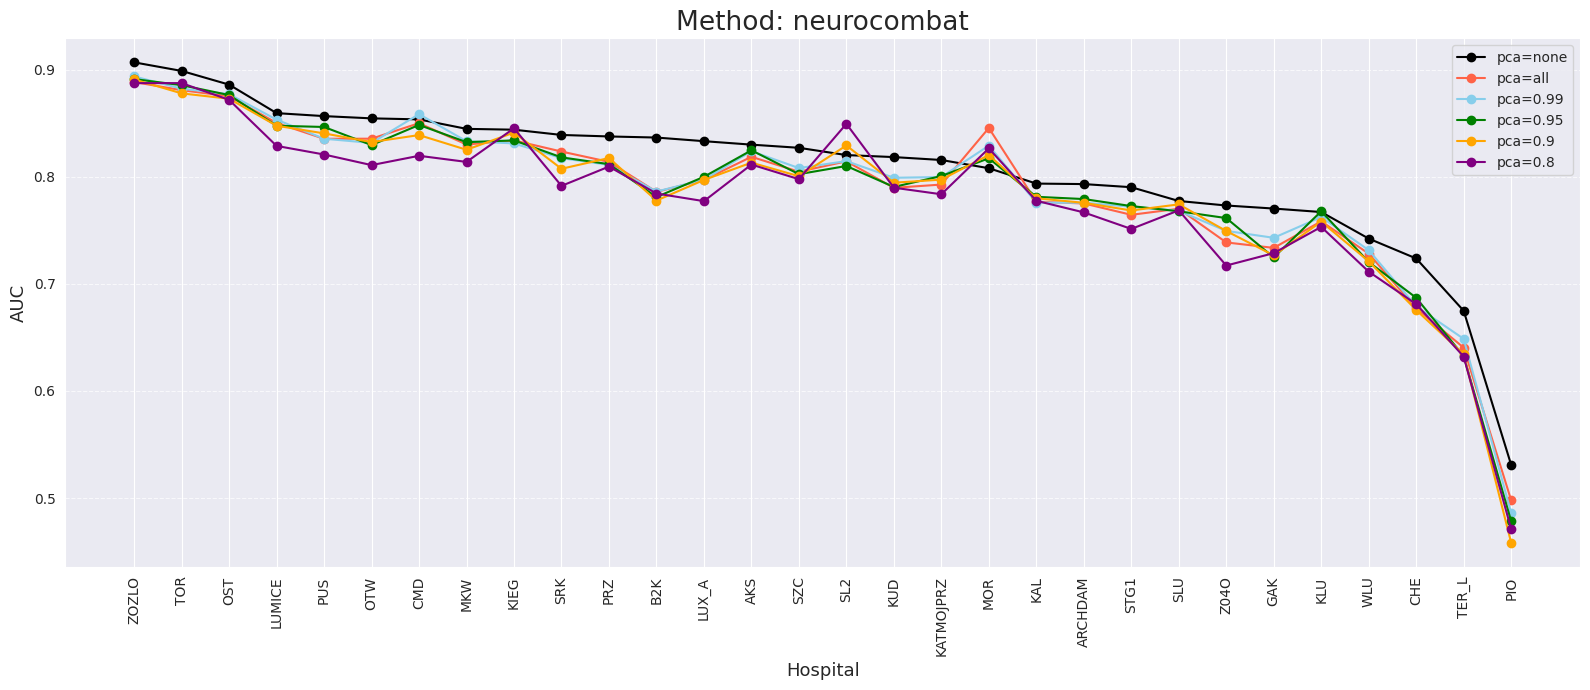

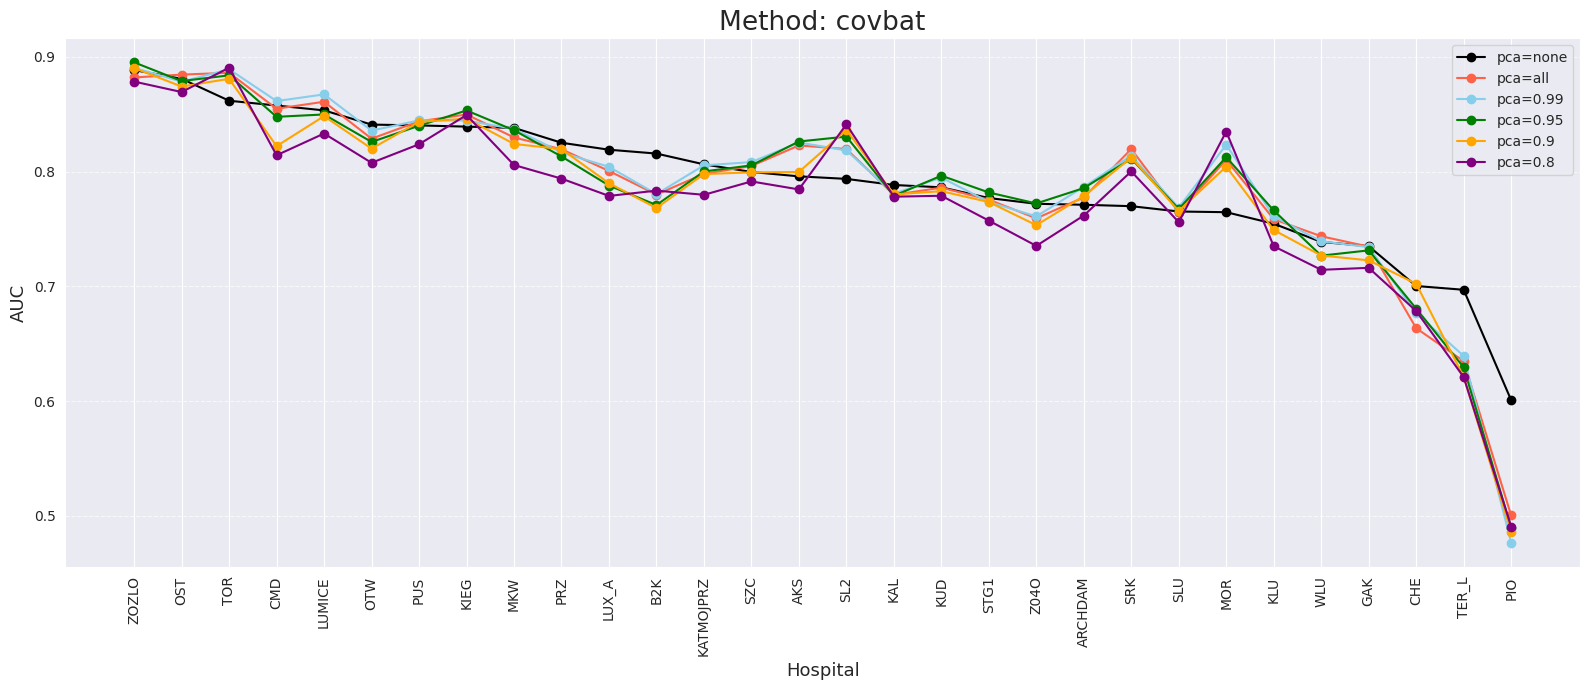

In [4]:
os.makedirs(FIGURES_DIR, exist_ok=True)

metric = 'auc'
for method in METHODS:
    pivot = patho_df[patho_df['method'] == method].pivot_table(
        index='pca_var', columns='hospital', values=metric
    )
    hospitals_sorted = pivot.loc['none'].sort_values(ascending=False).index.values

    fig, ax = plt.subplots(figsize=(16, 7))
    for i, pca in enumerate(PCA_VARIANTS):
        values = [pivot.loc[pca].get(h, float('nan')) for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=COLOR_GRID[i], label=f"pca={pca}")

    ax.set_title(f"Method: {method}", fontsize=19)
    ax.set_ylabel(metric.upper(), fontsize=13)
    ax.set_xlabel("Hospital", fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/patho_auc_method_{method}.png", dpi=150, bbox_inches='tight')
    plt.show()

## Pathology AUC per hospital — grouped by PCA variant

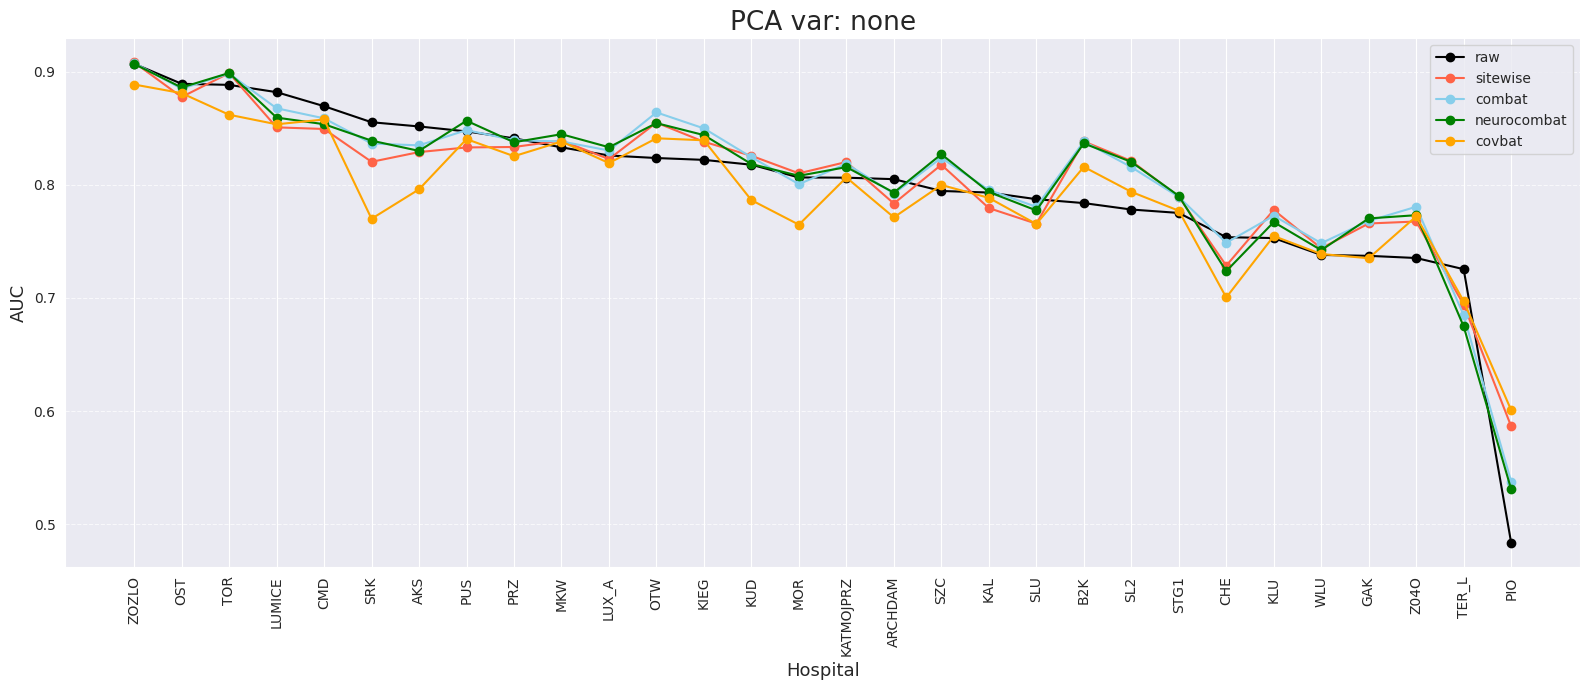

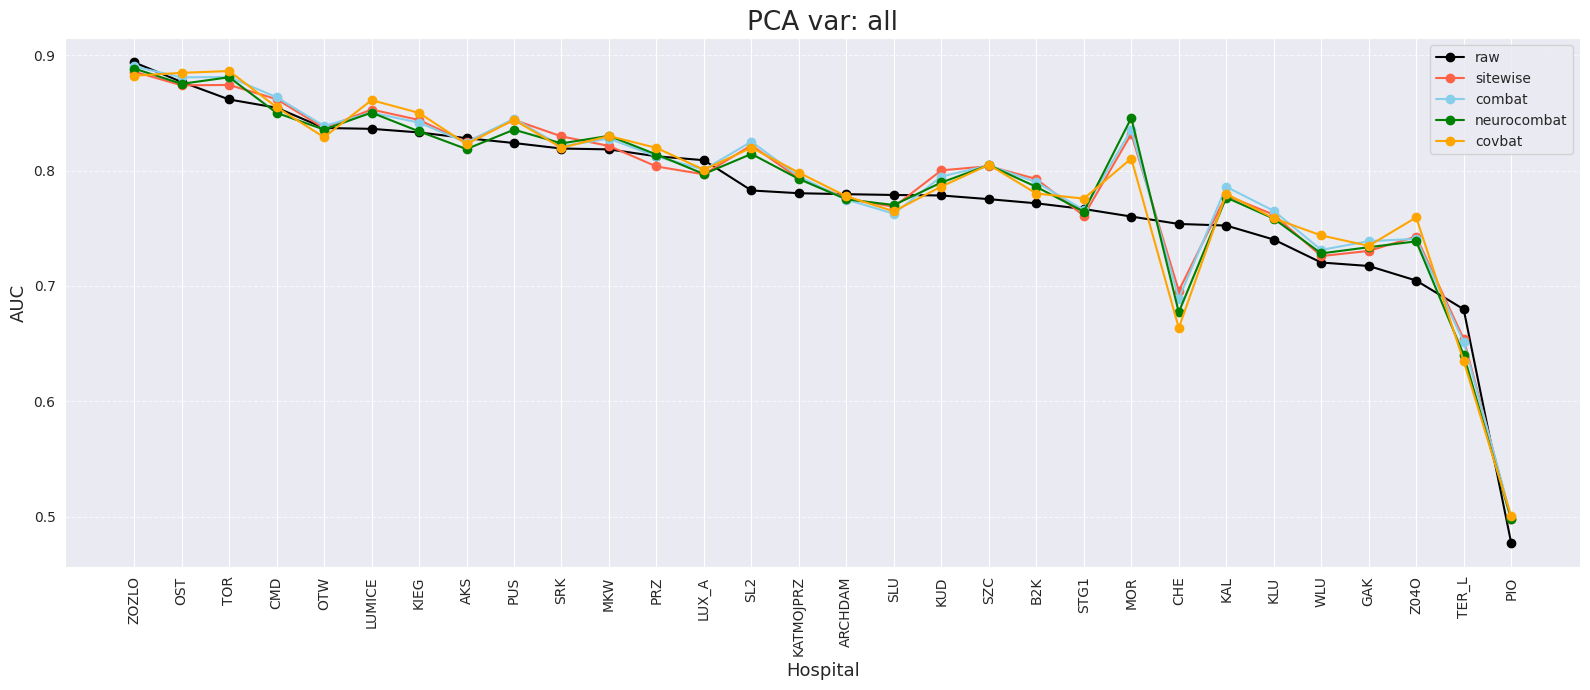

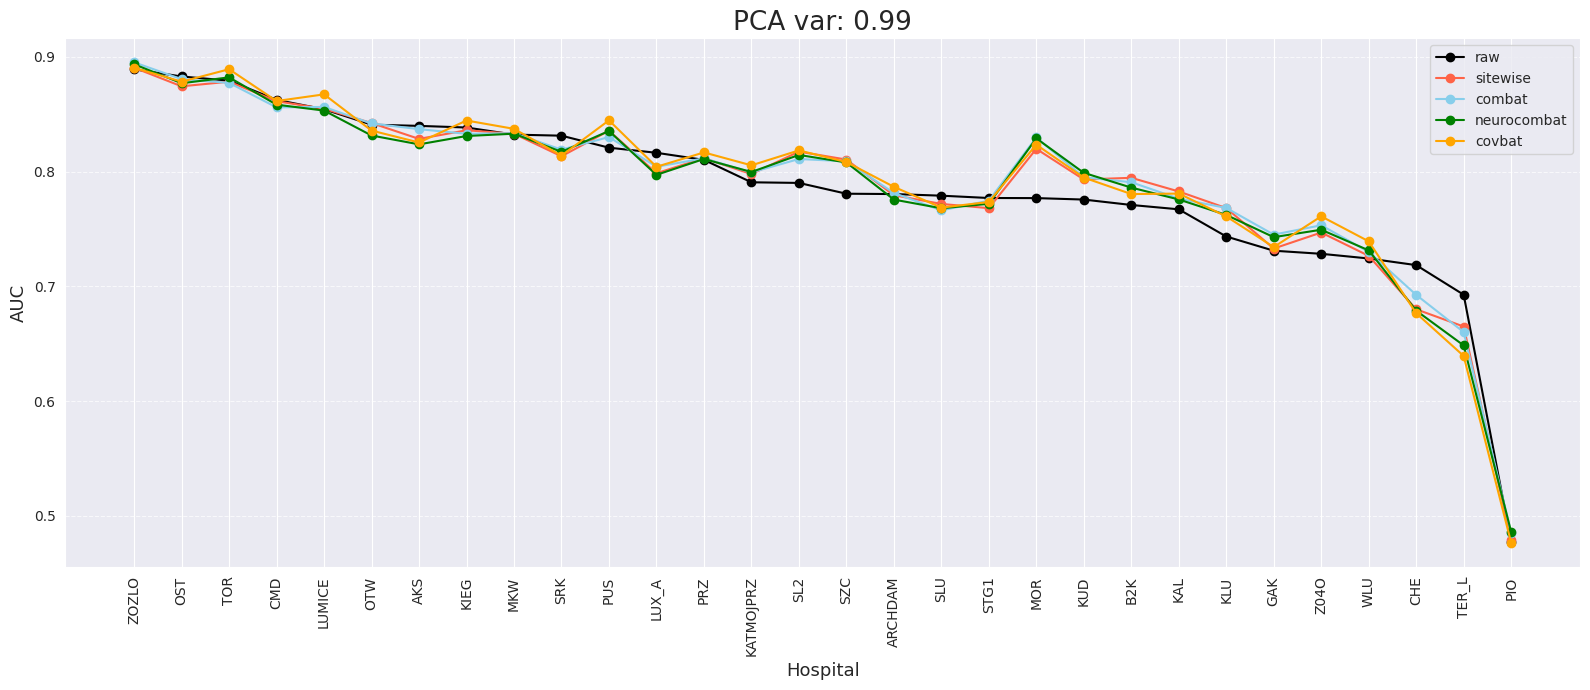

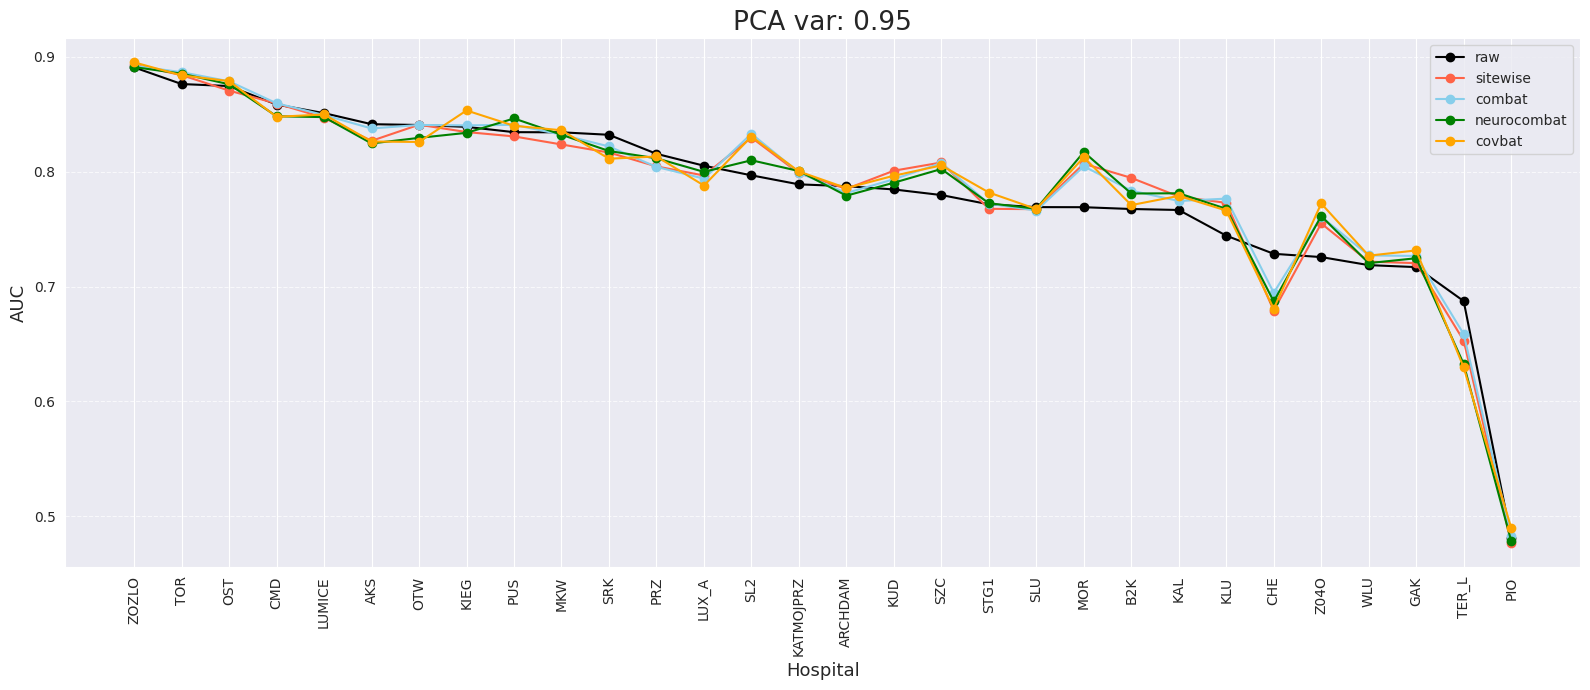

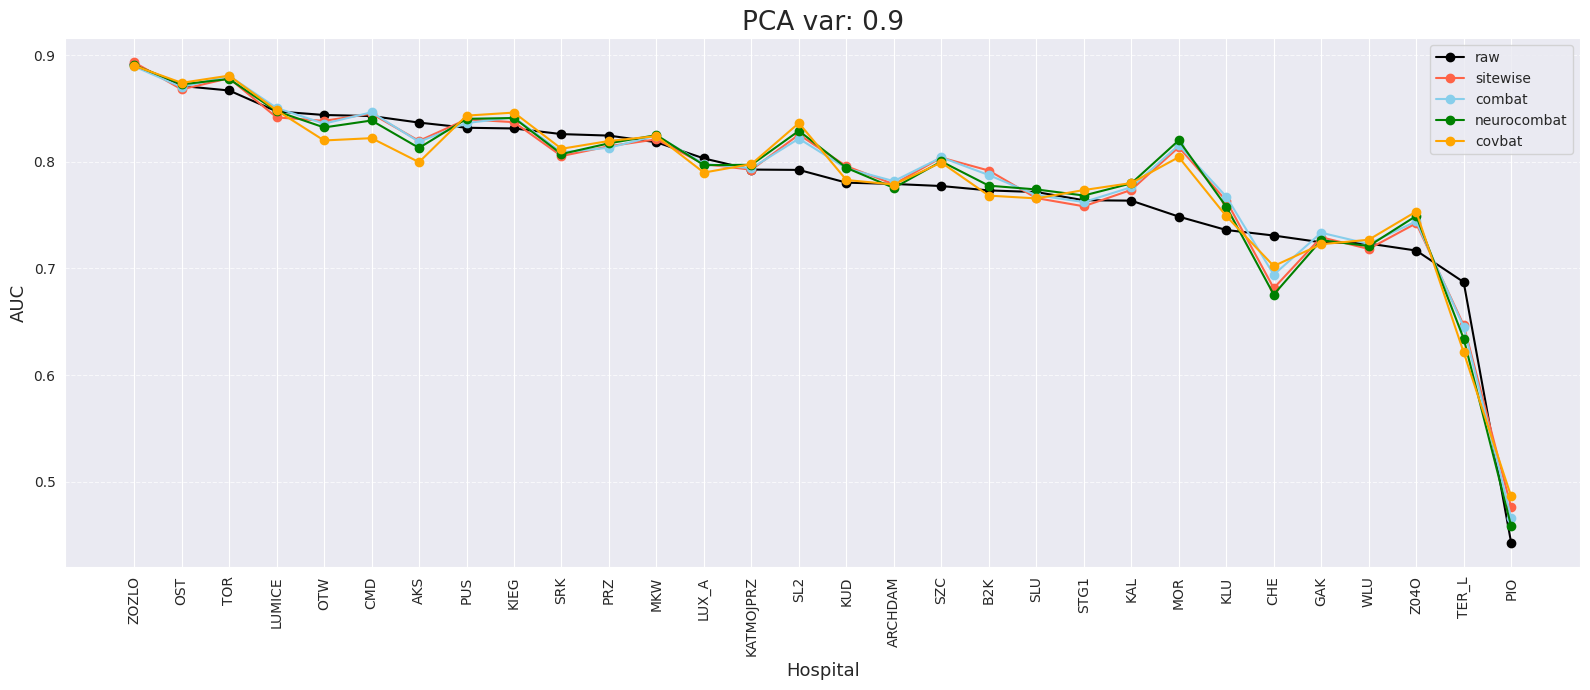

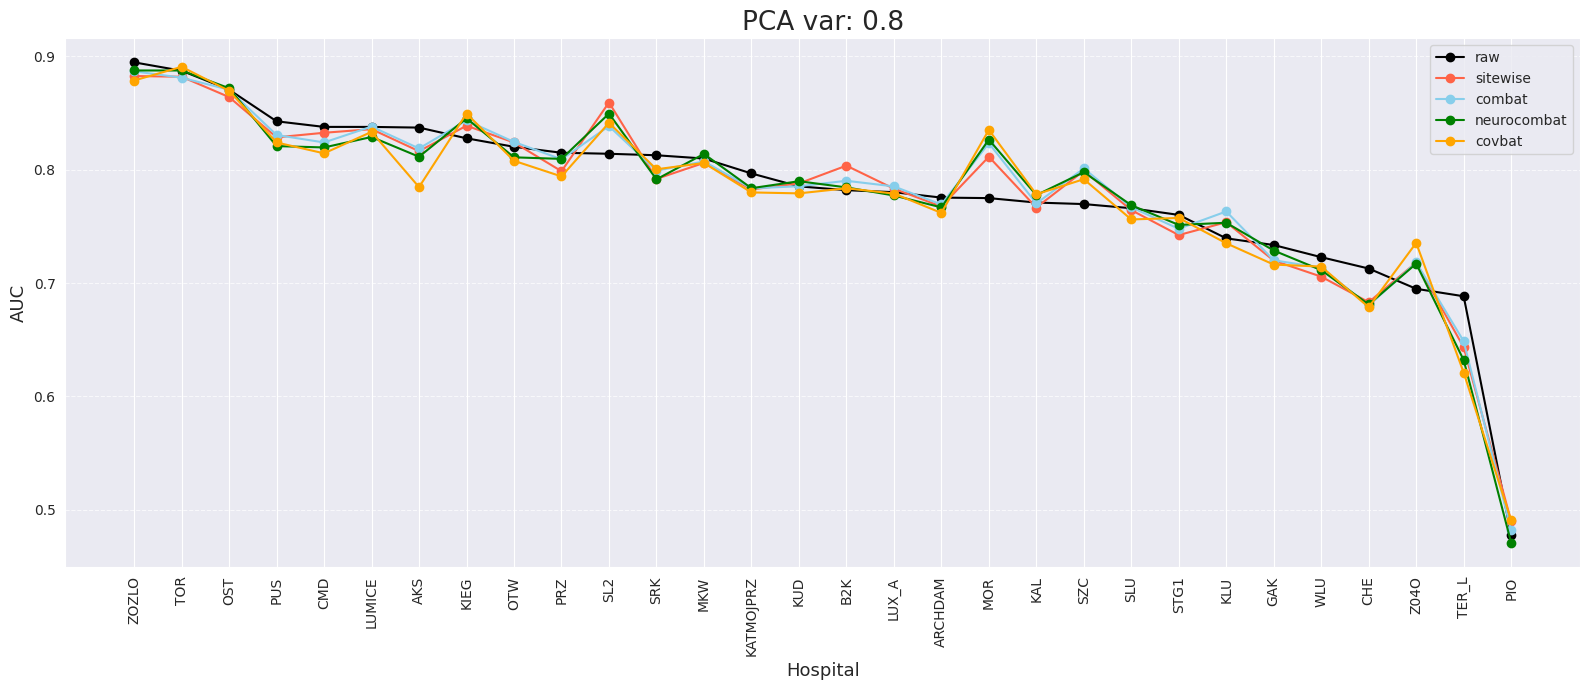

In [5]:
metric = 'auc'
for pca in PCA_VARIANTS:
    pivot = patho_df[patho_df['pca_var'] == pca].pivot_table(
        index='method', columns='hospital', values=metric
    )
    hospitals_sorted = pivot.loc['raw'].sort_values(ascending=False).index.values

    fig, ax = plt.subplots(figsize=(16, 7))
    for i, method in enumerate(METHODS):
        values = [pivot.loc[method].get(h, float('nan')) for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=COLOR_GRID[i], label=method)

    ax.set_title(f"PCA var: {pca}", fontsize=19)
    ax.set_ylabel(metric.upper(), fontsize=13)
    ax.set_xlabel("Hospital", fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/patho_auc_pca_{pca.replace('.', '')}.png", dpi=150, bbox_inches='tight')
    plt.show()